# Day 4 — Model Improvement + Evaluation (Final)
House Price Prediction (Gujrat, Gujranwala, Sialkot — Zameen.com)

Features: Size_Marla, Bedrooms, Bathrooms, City

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("../data/clean_data.csv")

model_df = pd.get_dummies(df, columns=["City"], drop_first=True)

feature_cols = [c for c in model_df.columns
                if c not in ["Price_PKR", "Price_per_Marla", "Title", "Price_Raw",
                             "Size_Raw", "Listing_URL", "Property_Type", "Location",
                             "Area", "Area_Grouped"]]

X = model_df[feature_cols]
y = model_df["Price_PKR"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Features:", feature_cols)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Features: ['Size_Marla', 'Bedrooms', 'Bathrooms', 'City_Gujrat', 'City_Jhelum', 'City_Sialkot', 'City_Wazirabad']
Train size: 1040 | Test size: 260


## Evaluation helper function

In [3]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model": model}
    print(f"{name} -> RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | R2: {r2:.3f}")
    return model

## Linear Regression (baseline)

In [4]:
_ = evaluate_model("Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test)

Linear Regression -> RMSE: 5,928,606 | MAE: 3,966,297 | R2: 0.783


## Random Forest

In [5]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
_ = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

Random Forest -> RMSE: 5,869,221 | MAE: 3,749,191 | R2: 0.787


## XGBoost

In [6]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
_ = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)

XGBoost -> RMSE: 5,939,537 | MAE: 3,792,216 | R2: 0.782


## Random Forest — Hyperparameter Tuning

In [7]:
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
_ = evaluate_model("Random Forest (Tuned)", search.best_estimator_, X_train, y_train, X_test, y_test)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30}
Random Forest (Tuned) -> RMSE: 5,881,184 | MAE: 3,771,301 | R2: 0.786


## Comparison table

In [8]:
comparison_df = pd.DataFrame({
    name: {"RMSE": r["RMSE"], "MAE": r["MAE"], "R2 Score": r["R2"]}
    for name, r in results.items()
}).T.sort_values("R2 Score", ascending=False)

comparison_df

,RMSE,MAE,R2 Score
Random Forest,5.869221e+06,3.749191e+06,0.786912
Random Forest (Tuned),5.881184e+06,3.771301e+06,0.786042
Linear Regression,5.928606e+06,3.966297e+06,0.782578
XGBoost,5.939537e+06,3.792216e+06,0.781775


## Feature importance

Best model: Random Forest


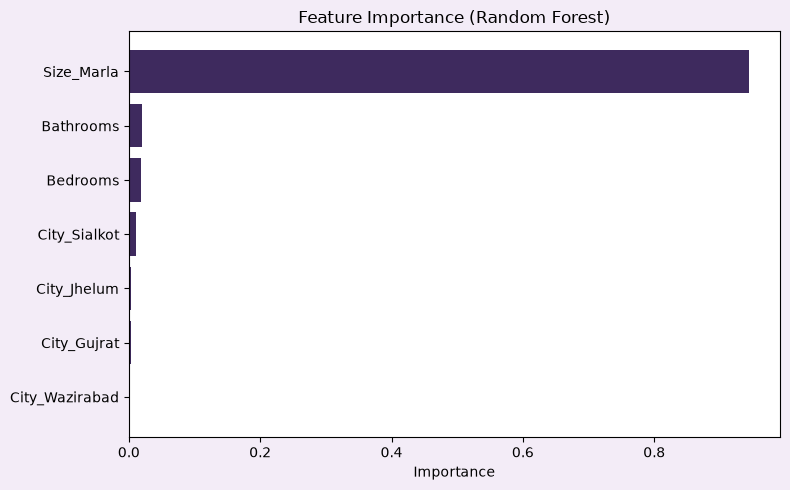

In [9]:
best_name = comparison_df.index[0]
best_model = results[best_name]["model"]
print(f"Best model: {best_name}")

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="#3E2A5E")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance ({best_name})")
    plt.gca().invert_yaxis()
    plt.gcf().patch.set_facecolor("#F3ECF7")
    plt.tight_layout()
    plt.savefig("../notebooks/feature_importance.png", dpi=120)
    plt.show()

    importance_df
else:
    print("Best model doesn't expose feature_importances_ (e.g. Linear Regression).")

## Save best model

In [10]:
joblib.dump(best_model, "../model.pkl")
joblib.dump(feature_cols, "../feature_cols.pkl")
print(f"Saved '{best_name}' as model.pkl")

Saved 'Random Forest' as model.pkl


## Predicted vs Actual — Model Verification
Ye graph batata hai model ki predictions kitni accurate hain. Agar model perfect hota,
sab points is diagonal (red) line pe hote — jitna points is line ke qareeb hain, utna
model ka performance acha hai.

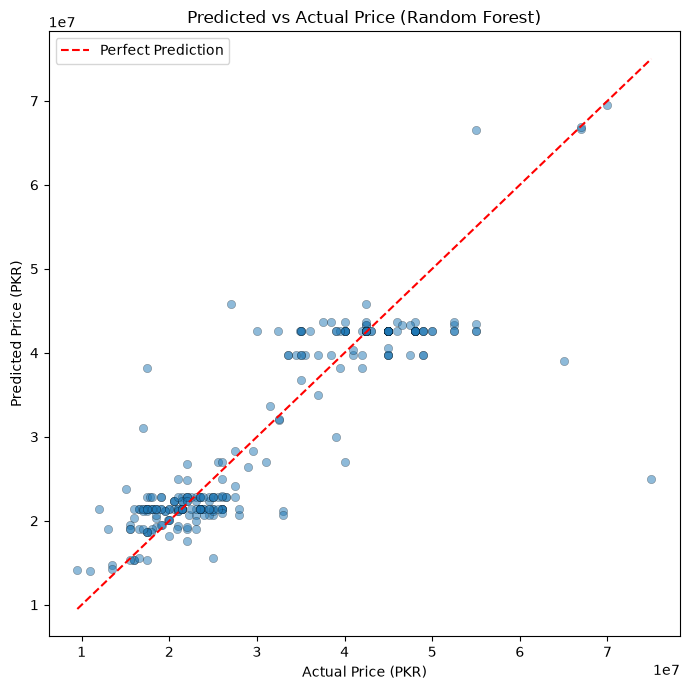

Model: Random Forest
Points close to the red line = accurate predictions.
Points far above the line = overpriced predictions.
Points far below the line = underpriced predictions.


In [ ]:
test_preds = best_model.predict(X_test)

min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_preds, alpha=0.6, color="#3E2A5E", edgecolor="#2E1F49", linewidth=0.3)
plt.plot([min_val, max_val], [min_val, max_val], color="#D4AF37", linestyle="--", linewidth=2, label="Perfect Prediction")
plt.gcf().patch.set_facecolor("#F3ECF7")

plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title(f"Predicted vs Actual Price ({best_name})")
plt.legend()
plt.tight_layout()
plt.savefig("../notebooks/predicted_vs_actual.png", dpi=120)
plt.show()

print(f"Model: {best_name}")
print("Points close to the gold line = accurate predictions.")
print("Points far above the line = overpriced predictions.")
print("Points far below the line = underpriced predictions.")